In [ ]:
"""Functions."""

In [ ]:
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np

Встроенные функции

In [1]:
# импортируем библиотеки

# установим точку отсчета
np.random.seed(42)
# и снова сгенерируем данные о росте (как мы делали на восьмом занятии вводного курса)
height = list(np.round(np.random.normal(180, 10, 1000)))

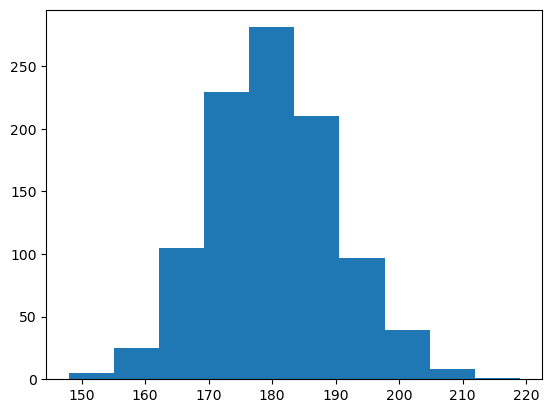

In [2]:
# теперь построим гистограмму передав ей два параметра, данные о росте и количество интервалов
# первый параметр у нас позиционный, второй - именованный
plt.hist(height, bins=10)
plt.show()

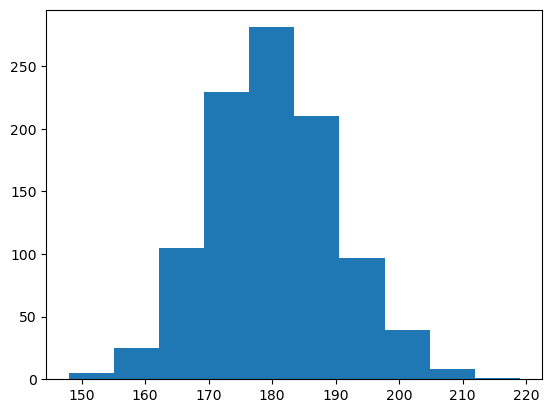

In [3]:
# первый параметр можно также сделать именованным (данные обозначаются через x)
# и тогда порядок параметров можно менять
plt.hist(bins=10, x=height)
plt.show()

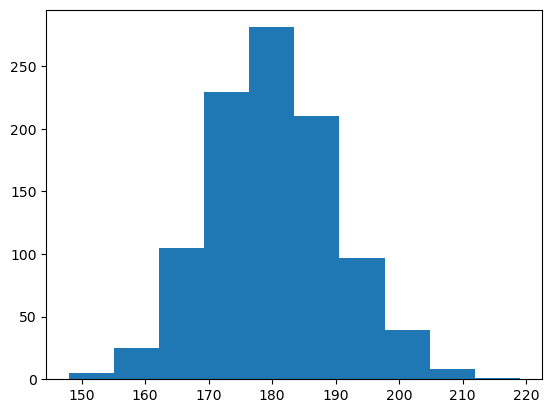

In [4]:
# у параметра bins есть аргумент по умолчанию (как раз 10 интервалов),
# а значит, этот параметр можно не указывать
plt.hist(height)
plt.show()

In [5]:
# функция может не принимать параметров
print("Первая строка")
print()
print("Третья строка")

Первая строка

Третья строка


Функции и методы

In [6]:
# дана строка
some_string = "machine learning"

# применим метод .title()
some_string.title()

'Machine Learning'

In [7]:
# к списку
some_list = ["machine", "learning"]

# этот метод не применить
some_list.title()  # type: ignore[attr-defined]

AttributeError: 'list' object has no attribute 'title'

Собственные функции в Питоне

In [8]:
# создадим функцию, которая удваивает любое передаваемое ей значение


def double(number: float) -> float:
    """Удвоить переданное число."""
    res = number * 2
    return res


# и вызовем ее, передав число 2
double(2)

4

Параметры собственных функций

In [1]:
# объявим функцию с параметрами num1 и num2


def calc_sum(num1: float, num2: float) -> float:
    """Вернуть сумму двух чисел."""
    # и выведем их сумму
    return num1 + num2


# вызовем эту функцию с одним позиционным и одним именованным параметром
calc_sum(1, num2=2)

3

In [2]:
# параметрам функции можно задать аргументы по умолчанию


def calc_sum_default(num1: float = 1, num2: float = 2) -> float:
    """Вернуть сумму двух чисел со значениями по умолчанию."""
    return num1 + num2


# и при вызове тогда их указывать не обязательно
calc_sum_default()

3

In [3]:
# укажем, что на входе функция принимает тип float, а возвращает int
# значение 3,5 - это значение параметра value по умолчанию


def f(value: float = 3.5) -> int:
    """Привести значение к типу int."""
    return int(value)


# желаемый тип данных можно посмотреть через атрибут __annotations__
f.__annotations__

{'x': float, 'return': int}

In [ ]:
# функция может возвращать также список, кортеж, словарь и др.


# объявим функцию, которая на входе получает число,
# а на выходе формирует список чисел от 0 и до числа, предшествующего заданному
def create_list(count: int) -> list[int]:
    """Создать список чисел от 0 до count не включительно."""
    # создадим пустой список
    numbers = []

    # в цикле for создадим последовательность
    for i in range(count):

        # и поместим ее в список
        numbers.append(i)

    return numbers


# результатом вызова этой функции будет список
create_list(5)

[0, 1, 2, 3, 4]

Использование библиотек

In [5]:
# применим функцию mean() библиотеки Numpy для расчета среднего арифметического


# на входе наша функция примет список или массив чисел,
def mean_f(values: list[float]) -> float:
    """Рассчитать среднее арифметическое и прибавить единицу."""
    # рассчитает среднее арифметическое и прибавит единицу
    return float(np.mean(values)) + 1


# перед вызовом функции нужно не забыть импортировать соответствующую библиотеку

# и подготовить данные
sample_values: list[float] = [1, 2, 3]

mean_f(sample_values)

np.float64(3.0)

Глобальные и локальные переменные

In [6]:
# создадим глобальную переменную вне функции
global_name = "Петр"


# а затем используем ее внутри новой функции
def show_name() -> None:
    """Вывести значение глобальной переменной global_name."""
    print(global_name)


show_name()

Петр


In [7]:
# а теперь вначале создадим функцию,
# внутри которой объявим локальную переменную


def show_local_name() -> None:
    """Вывести значение локальной переменной local_name."""
    local_name = "Алена"  # pylint: disable=redefined-outer-name
    print(local_name)


show_local_name()

Алена


In [8]:
# при попытке обратиться к переменной вне функции мы получим ошибку
local_name  # type: ignore[name-defined]  # pylint: disable=used-before-assignment

NameError: name 'local_name' is not defined

In [9]:
# превратить локальную переменную в глобальную можно через ключевое слово global


def make_global() -> None:
    """Объявить local_name глобальной переменной."""
    global local_name  # pylint: disable=global-variable-undefined
    local_name = "Алена"  # type: ignore[name-defined]
    print(local_name)  # type: ignore[name-defined]

In [10]:
make_global()

Алена


In [11]:
# теперь ошибки быть не должно
local_name  # type: ignore[name-defined]

'Алена'

Lambda-функции

In [1]:
# создадим функцию, которая принимает два числа и перемножает их
lf: Callable[[float, float], float] = (
    lambda a, b: a * b
)  # noqa: E731  # pylint: disable=unnecessary-lambda-assignment

# вызовем функцию и передадим ей числа 2 и 3
lf(2, 3)

6

In [2]:
# этот же функционал можно поместить в обычную функцию


def normal_f(num1: float, num2: float) -> float:
    """Перемножить два числа."""
    return num1 * num2


normal_f(2, 3)

6

Lambda-функция внутри функции filter()

In [4]:
# создадим список
numbers_list = [15, 27, 9, 18, 3, 1, 4]
# напишем lambda-функцию, которая выведет True, если число больше 10, и False, если меньше
list(filter(lambda n: n > 10, numbers_list))

[15, 27, 18]

Lambda-функция внутри функции sorted()

In [5]:
# мы создали список из кортежей,
# и в каждом кортеже был индекс фильма и расстояние до него
indices_distances = [
    (901, 0.0),
    (1002, 0.22982440568634488),
    (442, 0.25401128310081567),
]

# lambda-функция возьмет каждый кортеж и вернет второй [1] его элемент
# передав эту функцию через параметр key, мы отсортируем список по расстоянию
sorted(indices_distances, key=lambda x: x[1], reverse=False)

[(901, 0.0), (1002, 0.22982440568634488), (442, 0.25401128310081567)]

*args и **kwargs

In [6]:
# напишем функцию для расчета среднего арифметического двух чисел


def mean_two(num1: float, num2: float) -> float:
    """Рассчитать среднее арифметическое двух чисел."""
    return (num1 + num2) / 2

In [7]:
# объявим функцию с *args для любого количетсва чисел


def mean(*nums: float) -> float:
    """Рассчитать среднее арифметическое произвольного количества чисел."""
    # в данном случае мы складываем элементы кортежа
    total = 0.0
    for i in nums:
        total += i

    return total / len(nums)

In [8]:
mean(1, 2, 3, 4)

2.5

In [10]:
mean(*[1, 2, 3])

2.0

In [11]:
# *nums превращается в кортеж, **params - в словарь


def simple_stats(*nums: float, **params: bool) -> None:
    """Вывести среднее арифметическое и/или стандартное отклонение чисел."""
    # если ключ 'mean' есть в словаре params и его значение == True
    if "mean" in params and params["mean"] is True:

        # рассчитаем среднее арифметическое и округлим
        # \t - это символ табуляции
        print(f"mean: \t{np.round(np.mean(nums), 3)}")

    # если ключ 'std' есть в словаре params и его значение == True
    if "std" in params and params["std"] is True:

        # рассчитаем СКО и округлим
        print(f"std: \t{np.round(np.std(nums), 3)}")

In [14]:
# вызовем функцию simple_stats() и передадим ей числа и именованные аргументы
simple_stats(5, 10, 15, 20, mean=True, std=True)

mean: 	12.5
std: 	5.59


In [15]:
# если для одного из параметров задать значение False,
# функция не выведет соответствующую метрику
simple_stats(5, 10, 15, 20, mean=True, std=False)

mean: 	12.5


In [16]:
# если мы хотим передать параметры списком и словарем,
list_ = [5, 10, 15, 20]
settings = {"mean": True, "std": True}

# то нам нужно использовать операторы распаковки * и ** соответственно
simple_stats(*list_, **settings)

mean: 	12.5
std: 	5.59
